In [4]:
import pandas as pd
import nltk
from collections import Counter
import itertools
import numpy as np
from sklearn.metrics import accuracy_score

In [5]:
class NaiveBayesClassifier:
    def __init__(self, train, types):
        self.smooth = 0.00001
        self.train = train
        self.types = types
        self.all_word_ctr = Counter([word for row in train for word in row])
        self.all_type_ctr = Counter(types)
        self.type_ctrs = {}
        for _type in set(types):
            type_rows = [train[i] for i in range(len(train)) if types[i] == _type]
            type_words = [word for row in type_rows for word in row]
            self.type_ctrs[_type] = Counter(type_words)
        
    def Pt(self, T=''):
        return self.all_type_ctr[T] / len(self.train)

    def Pw(self, W=''):
        if W not in self.all_word_ctr:
            return self.smooth
        else:
            return self.all_word_ctr[W] / len(self.train)
        
    def Pwt(self, W='', T=''):
        if W not in self.type_ctrs[T]:
            return self.smooth
        else:
            return self.type_ctrs[T][W] / self.all_type_ctr[T]
        
    def Ptw(self, W='', T=''):
        return self.Pwt(W, T) * self.Pt(T) / self.Pw(W)
        
    def Ptsentence(self, T='', S=''):
        return np.prod([self.Ptw(word, T) for word in S])
    
    def classify(self, sentence):
        probs = [(_type, self.Ptsentence(_type, sentence)) for _type in set(self.types)]
        return max(probs, key=lambda x: x[1])[0]
    
    def classify_all(self, test, types):
        hyp = [self.classify(sentence) for sentence in test]
        return accuracy_score(hyp, types)

In [6]:
data = pd.read_csv('C:/Users/Sharadha Kasi/pnp-train.txt', delimiter='\t', encoding='latin-1', names=['type','name']) 
data[:10]  

,type,name
0,drug,Dilotab
1,movie,Beastie Boys: Live in Glasgow
2,person,Michelle Ford-Eriksson
3,place,Ramsbury
4,place,Market Bosworth
5,drug,Cyanide Antidote Package
6,person,Bill Johnson
7,place,Ettalong
8,movie,The Suicide Club
9,place,Pézenas


In [7]:
train = pd.read_csv('C:/Users/Sharadha Kasi/pnp-train.txt',delimiter='\t',encoding='latin-1', names=['type','name'])
train['clean'] = train.name.map(lambda x: x.lower().split())
nbc = NaiveBayesClassifier(list(train.clean), list(train.type))

In [15]:
test = train.sample(frac=0.1)
test.shape

(2100, 3)

In [16]:
with open('C:/Users/Sharadha Kasi/pnp-test.txt', 'w', encoding='latin-1') as file:
    for index, row in test.iterrows():
        file.write(f"{row['type']}\t{row['name']}\n")
test = pd.read_csv('C:/Users/Sharadha Kasi/pnp-test.txt', delimiter='\t', encoding='latin-1', header=None, names=['type', 'name'])
test['clean'] = test.name.map(lambda x: x.lower().split())

In [17]:
print("Naive Bayes Accuracy = ", nbc.classify_all(list(test.clean), list(test.type)))

Naive Bayes Accuracy =  0.9857142857142858


In [18]:
print("Random Baseline = ", 1 / len(set(nbc.types)))
print("Most Common Baseline = ", nbc.all_type_ctr.most_common()[0][1] / len(nbc.train))

Random Baseline =  0.2
Most Common Baseline =  0.29817627732012764


#### What are the two baselines for this particular task? How did you determine the two baselines?

The two baselines for this task are the random baseline and the common baseline. I determined the random baseline by taking reciprocal of the number of unique types in the dataset. For the most common baseline, I calculated the frequency of the most common type and divided it by the total number of samples.

#### What is the accuracy of your classifier?

The accuracy of my Naive Bayes classifier is approximately 98%.

#### What kind of normalization did you apply? Why does it make sense to do that for this particular task? How does your accuracy change if you don’t apply that normalization strategy?

I applied case normalization by converting all the names to lowercase. I thought that this normalization would be better because names are case-insensitive in this context. Without case normalization, the accuracy might be affected as the model may treat differently cased versions of the same word as distinct. The accuracy might slightly decrease due to this.

#### What modeling approach did you use? I.e., how did you model the probability of a name (a sequence of words)?

I used a Naive Bayes modeling approach for the probability of a name (a sequence of words). The model calculates the probability of a given type for a name by assuming independence between the occurrences of individual words within the name.
This assumption allowed to decompose the joint probability of the features and the class into the product of individual conditional probabilities of each feature given the class.

#### What assumptions does your model make?

The assumptions of the Naive Bayes model include independence between features (words in this case) and the conditional independence of each feature given the class label.

#### Create a confusion matrix of your model’s predictions/guesses vs. the real types. What do you notice?

<Figure size 1000x1000 with 0 Axes>

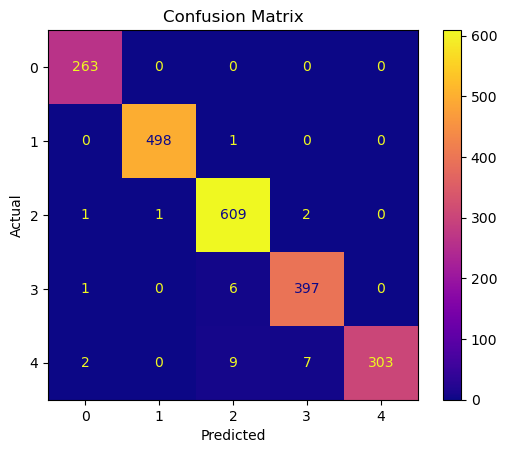

In [19]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

prediction = [nbc.classify(sentence) for sentence in test.clean]
actual = list(test.type)
cmx = confusion_matrix(actual, prediction)
plt.figure(figsize=(10, 10))
display = ConfusionMatrixDisplay(confusion_matrix = cmx)
display.plot(cmap='plasma', xticks_rotation='horizontal')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

From the confusion matrix, we can observe how well the model performs for each type. The diagonal elements represent the number of correct predictions for each type, while off-diagonal elements represent the misclassifications. From this, we can see which types are often confused with each other.

In [21]:
distinct_classes = sorted(test['type'].unique())
distinct_classes

['company', 'drug', 'movie', 'person', 'place']

So, here the axes 0,1,2,3,4 respectively represent- 'company', 'drug', 'movie', 'person', 'place'. 

0- Company
1- Drug
2- Movie
3- Person
4- Place

(For example: for the Company(0), the diagram shows- 263 predictions were correct (true positives) and totally 4 predictions were incorrect). Like this we can correctly identify where the classifier is going wrong.

In [23]:
train['clean'] = train.name.map(lambda x: x.split())
test['clean'] = test.name.map(lambda x: x.split())
nbc = NaiveBayesClassifier(list(train.clean), list(train.type))
accuracywn = nbc.classify_all(list(test.clean), list(test.type))
print("Accuracy without normalization:", accuracywn)

Accuracy without normalization: 0.9866666666666667


In [24]:
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

# Download NLTK resources
nltk.download('punkt')
nltk.download('stopwords')

# Initialize Porter Stemmer and get stopwords
stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))

# Function to preprocess a name
def preprocess_name(name):
    # Tokenize the name into words
    words = name.split()
    # Remove stop words and apply stemming or lemmatization
    clean_words = [stemmer.stem(word) for word in words if word.lower() not in stop_words]
    return clean_words

# Apply preprocessing to the names in the dataset
train['clean'] = train.name.map(preprocess_name)
test['clean'] = test.name.map(preprocess_name)

# Initialize and train the Naive Bayes classifier
nbc = NaiveBayesClassifier(list(train.clean), list(train.type))

# Calculate accuracy with preprocessing
accuracy_with_preprocessing = nbc.classify_all(list(test.clean), list(test.type))
print("Accuracy with preprocessing:", accuracy_with_preprocessing)

[nltk_data] Downloading package punkt to C:\Users\Sharadha
[nltk_data]     Kasi\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\Sharadha
[nltk_data]     Kasi\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Accuracy with preprocessing: 0.9833333333333333
